<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/power/combined_cycle_power_plant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Natural-gas combined-cycle power plant with NeqSim

This standalone example couples a Brayton gas turbine to a single-pressure heat-recovery steam
generator (HRSG) and Rankine bottoming cycle. It complements the existing gas-fired, ammonia,
compressor, and expander notebooks; it does not replace them.

**Audience.** Process, mechanical, energy, and chemical engineers who know basic thermodynamics
and want a transparent screening model before using vendor-grade gas-turbine or HRSG software.

**Prerequisites.** Familiarity with steady-flow energy balances, isentropic efficiency, phase
equilibrium, and Python. No local files, credentials, or proprietary performance maps are needed.


## Learning objectives

After working through the notebook, you can:

1. calculate natural-gas lower heating value with NeqSim's ISO 6976 implementation;
2. build and audit a Brayton compressor, atom-balanced combustor, and gas turbine;
3. represent liquid water and two-phase steam with NeqSim's CPA equation of state;
4. solve a feedwater pump and condensing steam turbine from enthalpy and entropy constraints;
5. couple the gas and steam cycles through an HRSG energy balance;
6. calculate net power, LHV efficiency, direct carbon intensity, and steam quality;
7. cross-check manual thermodynamic operations against NeqSim process equipment; and
8. examine pressure-ratio and steam-pressure sensitivities with explicit validity checks.


## Plant boundary and solver workflow

The model has two working fluids and one thermal coupling:

- **Gas side:** dry air is compressed, mixed conceptually with fuel, burned completely, expanded,
  and cooled to a specified stack temperature.
- **Water side:** condensate is pumped, heated and vaporized in the HRSG, expanded through a steam
  turbine, and condensed.
- **Coupling:** the HRSG transfers the gas-side enthalpy decrease to the water side with a stated
  effectiveness. The two fluids never mix.

NeqSim represents each fluid as a thermodynamic system. `TPflash`, `PSflash`, and `PHflash` solve
temperature-pressure, entropy-pressure, and enthalpy-pressure states. Streams attach flow rates to
those states, while compressor and expander objects reproduce the principal rotating-equipment
calculations. The notebook first exposes the equations, then cross-checks them with process objects.


## Steady-flow energy equations

For an adiabatic compressor with isentropic efficiency $\eta_c$, the actual outlet enthalpy is

$$
h_2 = h_1 + \frac{h_{2s}-h_1}{\eta_c}
$$

For a turbine with isentropic efficiency $\eta_t$,

$$
h_4 = h_3 - \eta_t\left(h_3-h_{4s}\right)
$$

Here $h$ is specific enthalpy in kJ/kg. The subscript $s$ denotes the isentropic outlet found from
a `PSflash`. These equations neglect kinetic-energy, potential-energy, casing heat-loss, and
mechanical-loss terms inside each thermodynamic unit.


## Combustion and fuel basis

For complete combustion of a hydrocarbon represented as $\mathrm{C}_a\mathrm{H}_b$, the required
oxygen is

$$
\nu_{\mathrm{O_2,st}} = a + \frac{b}{4}
$$

The combustor is solved by bisection on fuel flow until the product sensible-enthalpy rise equals
the fuel LHV plus the inlet sensible enthalpy. Nitrogen and fuel carbon dioxide are carried through.
The model assumes complete combustion, no carbon monoxide, no unburned hydrocarbons, and no
high-temperature dissociation. Those assumptions are suitable for cycle screening, not emissions
guarantees.


## HRSG and Rankine-cycle balances

The gas-side recoverable heat is

$$
\dot Q_{\mathrm{gas}} =
\dot m_{\mathrm{gas}}\left(h_{\mathrm{GT,out}}-h_{\mathrm{stack}}\right)
$$

With HRSG effectiveness $\varepsilon_{\mathrm{HRSG}}$, the generated steam flow is

$$
\dot m_s =
\frac{\varepsilon_{\mathrm{HRSG}}\dot Q_{\mathrm{gas}}}
{h_3-h_2}
$$

The steam-cycle net electric power is generator efficiency times turbine shaft power minus pump
shaft power. A real HRSG also requires pinch-point, approach-temperature, pressure-drop, drum,
circulation, and heat-transfer-area calculations. This single-pressure energy model is a
concept-screening limit, not an HRSG design.


## Pump work and combined performance

For nearly incompressible condensate, the feedwater-pump work is screened from

$$
w_p = \frac{v\left(P_2-P_1\right)}{\eta_p}
$$

where $v$ is liquid specific volume in m³/kg, pressure is in Pa, and $w_p$ is converted to kJ/kg.
The combined-cycle LHV efficiency is

$$
\eta_{\mathrm{CC}} =
\frac{\dot W_{\mathrm{GT,net}}+\dot W_{\mathrm{ST,net}}}
{\dot m_f LHV}
$$

All flow rates are in kg/s, powers and heat rates in kW or MW, pressures in bara, and temperatures
in K unless a table states otherwise.


## Assumptions and reproducible design point

The synthetic fuel is 90 mol% methane with small ethane, propane, carbon dioxide, and nitrogen
fractions. The gas turbine uses 100 kg/s dry air, pressure ratio 18, 1500 K turbine-inlet
temperature, and stated isentropic efficiencies. The Rankine cycle uses 100 bara, 450°C steam and a
0.05 bara condenser.

The steam conditions are deliberately below the gas-turbine exhaust temperature. The notebook
checks the hot-end temperature approach and outlet quality, but it does not predict metal
temperatures, cooling-air extraction, blade maps, pressure losses beyond the stated combustor loss,
or off-design control behavior.


## 1. Colab setup

The first executable cell installs the verified public PyPI release only when the runtime does not
already have that version. A runtime restart is not required. The notebook never loads a local
NeqSim checkout or unpublished JAR.


In [1]:
import importlib.metadata
import importlib.util
import subprocess
import sys


VERIFIED_NEQSIM_VERSION = "3.16.0"
installed_version = None
if importlib.util.find_spec("neqsim") is not None:
    installed_version = importlib.metadata.version("neqsim")

if installed_version != VERIFIED_NEQSIM_VERSION:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            f"neqsim=={VERIFIED_NEQSIM_VERSION}",
        ]
    )


## 2. Imports and runtime record

NeqSim's Python package starts a Java Virtual Machine and exposes the Java thermodynamic systems.
Pandas formats audit tables, NumPy supports finite checks, and Matplotlib creates deterministic
engineering plots.


In [2]:
import json
import platform
import subprocess
from importlib import metadata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from neqsim import jneqsim
from neqsim.process import clearProcess, compressor, expander, runProcess, stream
from neqsim.standards import ISO6976


neqsim_version = metadata.version("neqsim")
java_version_line = subprocess.run(
    ["java", "-version"],
    capture_output=True,
    check=True,
    text=True,
).stderr.splitlines()[0]

print(f"Python version: {platform.python_version()}")
print(f"NeqSim package version: {neqsim_version}")
print(f"Java runtime: {java_version_line}")


Python version: 3.12.13
NeqSim package version: 3.16.0
Java runtime: openjdk version "17.0.19" 2026-04-21


## 3. Thermodynamic-system helpers

The gas cycle uses the Soave–Redlich–Kwong equation of state (SRK), a common cubic model for
natural gas, air, and combustion products. The water cycle uses NeqSim's SRK-CPA system because the
association term improves the representation of strongly hydrogen-bonding water.

Each helper returns an independently flashed state. Cloning is used later so one calculation cannot
silently mutate an upstream state.


In [3]:
THERMODYNAMIC_OPERATIONS = jneqsim.thermodynamicoperations.ThermodynamicOperations
REFERENCE_TEMPERATURE_K = 298.15
AIR_OXYGEN_FRACTION = 0.21
AIR_NITROGEN_FRACTION = 0.79
CO2_MOLAR_MASS_KG_KMOL = 44.0095


def initialize_properties(fluid):
    operations = THERMODYNAMIC_OPERATIONS(fluid)
    operations.TPflash()
    fluid.initProperties()
    return fluid


def make_srk_fluid(composition, temperature_k, pressure_bara):
    fluid = jneqsim.thermo.system.SystemSrkEos(
        temperature_k,
        pressure_bara,
    )
    for component_name, mole_fraction in composition.items():
        fluid.addComponent(component_name, mole_fraction)
    fluid.setMixingRule("classic")
    fluid.init(0)
    return initialize_properties(fluid)


def make_air(temperature_k, pressure_bara):
    return make_srk_fluid(
        {
            "nitrogen": AIR_NITROGEN_FRACTION,
            "oxygen": AIR_OXYGEN_FRACTION,
        },
        temperature_k,
        pressure_bara,
    )


def make_water(temperature_k, pressure_bara):
    fluid = jneqsim.thermo.system.SystemSrkCPAstatoil(
        temperature_k,
        pressure_bara,
    )
    fluid.addComponent("water", 1.0)
    fluid.setMixingRule(10)
    return initialize_properties(fluid)


## 4. Design inputs

Inputs are collected in one cell to prevent unexplained numbers from being scattered through the
model. Efficiencies are fractions, the combustor pressure loss is relative, and the HRSG
effectiveness represents recoverable gas heat delivered to water. The 393.15 K stack target is an
illustrative screening constraint, not a corrosion or permitting guarantee.


In [4]:
fuel_composition = {
    "methane": 0.900,
    "ethane": 0.050,
    "propane": 0.015,
    "CO2": 0.020,
    "nitrogen": 0.015,
}

ambient_temperature_k = 288.15
ambient_pressure_bara = 1.01325
air_mass_flow_kg_s = 100.0
gas_pressure_ratio = 18.0
gas_compressor_efficiency = 0.86
combustor_pressure_loss_fraction = 0.04
turbine_inlet_temperature_k = 1500.0
gas_turbine_efficiency = 0.90
gas_exhaust_pressure_bara = 1.05
gas_generator_efficiency = 0.985

stack_temperature_k = 393.15
hrsg_effectiveness = 0.94
steam_pressure_bara = 100.0
steam_temperature_k = 723.15
condenser_pressure_bara = 0.05
condensate_temperature_k = 303.15
feedwater_pump_efficiency = 0.80
steam_turbine_efficiency = 0.86
steam_generator_efficiency = 0.985
minimum_hot_end_approach_k = 30.0

assert abs(sum(fuel_composition.values()) - 1.0) < 1.0e-12


## 5. Fuel quality from ISO 6976

NeqSim's ISO 6976 calculation supplies the mass-basis heating values. LHV is used because the
cycle does not condense combustion water and therefore does not recover its latent heat. HHV is
reported only for context.


In [5]:
fuel = make_srk_fluid(
    fuel_composition,
    ambient_temperature_k,
    ambient_pressure_bara,
)
fuel_molar_mass_kg_kmol = fuel.getMolarMass() * 1000.0

iso6976 = ISO6976(fuel)
iso6976.setReferenceType("mass")
iso6976.setVolRefT(15.0)
iso6976.setEnergyRefT(15.0)
iso6976.calculate()

fuel_lhv_kj_kg = iso6976.getValue("InferiorCalorificValue")
fuel_hhv_kj_kg = iso6976.getValue("SuperiorCalorificValue")
relative_density = iso6976.getValue("RelativeDensity")

fuel_quality_table = pd.DataFrame(
    {
        "Quantity": ["Molar mass", "LHV", "HHV", "Relative density"],
        "Value": [
            fuel_molar_mass_kg_kmol,
            fuel_lhv_kj_kg / 1000.0,
            fuel_hhv_kj_kg / 1000.0,
            relative_density,
        ],
        "Unit": ["kg/kmol", "MJ/kg", "MJ/kg", "-"],
    }
)
display(fuel_quality_table.round(5))


,Quantity,Value,Unit
0,Molar mass,17.90406,kg/kmol
1,LHV,46.05177,MJ/kg
2,HHV,51.04025,MJ/kg
3,Relative density,0.61932,-


## 6. Stoichiometric basis and carbon factor

The component database provides elemental counts for hydrocarbons. Fuel carbon dioxide and nitrogen
are treated as inerts. This explicit atom balance is more transparent than assigning a fixed air–fuel
ratio and makes the direct carbon factor traceable to the selected composition.


In [6]:
def fuel_atom_basis(fuel_fluid):
    basis = {
        "hydrocarbon_carbon": 0.0,
        "hydrocarbon_hydrogen": 0.0,
        "fuel_CO2": 0.0,
        "fuel_nitrogen": 0.0,
    }
    component_count = int(fuel_fluid.getNumberOfComponents())
    for component_index in range(component_count):
        component = fuel_fluid.getComponent(component_index)
        name = str(component.getName())
        fraction = float(component.getz())
        if component.isHydrocarbon():
            elements = component.getElements()
            basis["hydrocarbon_carbon"] += (
                fraction * elements.getNumberOfElements("C")
            )
            basis["hydrocarbon_hydrogen"] += (
                fraction * elements.getNumberOfElements("H")
            )
        elif name == "CO2":
            basis["fuel_CO2"] += fraction
        elif name == "nitrogen":
            basis["fuel_nitrogen"] += fraction
    return basis


atom_basis = fuel_atom_basis(fuel)
stoichiometric_oxygen_kmol_kmol = (
    atom_basis["hydrocarbon_carbon"]
    + atom_basis["hydrocarbon_hydrogen"] / 4.0
)
air_reference = make_air(REFERENCE_TEMPERATURE_K, ambient_pressure_bara)
air_molar_mass_kg_kmol = air_reference.getMolarMass() * 1000.0
stoichiometric_air_kmol_kmol = (
    stoichiometric_oxygen_kmol_kmol / AIR_OXYGEN_FRACTION
)
stoichiometric_afr_kg_kg = (
    stoichiometric_air_kmol_kmol
    * air_molar_mass_kg_kmol
    / fuel_molar_mass_kg_kmol
)
co2_kmol_per_kmol_fuel = (
    atom_basis["hydrocarbon_carbon"] + atom_basis["fuel_CO2"]
)
co2_kg_per_kg_fuel = (
    co2_kmol_per_kmol_fuel
    * CO2_MOLAR_MASS_KG_KMOL
    / fuel_molar_mass_kg_kmol
)

stoichiometry_table = pd.DataFrame(
    {
        "Quantity": [
            "Stoichiometric oxygen",
            "Stoichiometric dry air",
            "Stoichiometric AFR",
            "Direct CO2 factor",
        ],
        "Value": [
            stoichiometric_oxygen_kmol_kmol,
            stoichiometric_air_kmol_kmol,
            stoichiometric_afr_kg_kg,
            co2_kg_per_kg_fuel,
        ],
        "Unit": [
            "kmol O2/kmol fuel",
            "kmol air/kmol fuel",
            "kg air/kg fuel",
            "kg CO2/kg fuel",
        ],
    }
)
display(stoichiometry_table.round(6))


,Quantity,Value,Unit
0,Stoichiometric oxygen,2.050000,kmol O2/kmol fuel
1,Stoichiometric dry air,9.761905,kmol air/kmol fuel
2,Stoichiometric AFR,15.730255,kg air/kg fuel
3,Direct CO2 factor,2.617849,kg CO2/kg fuel


## 7. Reusable compressor and turbine flashes

The helpers first calculate the isentropic outlet with a `PSflash`, then apply the efficiency
definition and recover the actual state with a `PHflash`. The same expander helper works for both
dry combustion gas and condensing steam because each fluid carries its own thermodynamic model.


In [7]:
def compress_fluid(inlet_fluid, outlet_pressure_bara, efficiency):
    isentropic_outlet = inlet_fluid.clone()
    isentropic_outlet.setPressure(outlet_pressure_bara, "bara")
    inlet_entropy_kj_kgk = inlet_fluid.getEntropy("kJ/kgK")
    THERMODYNAMIC_OPERATIONS(isentropic_outlet).PSflash(
        inlet_entropy_kj_kgk,
        "kJ/kgK",
    )
    isentropic_outlet.initProperties()

    inlet_enthalpy_kj_kg = inlet_fluid.getEnthalpy("kJ/kg")
    isentropic_enthalpy_kj_kg = isentropic_outlet.getEnthalpy("kJ/kg")
    actual_enthalpy_kj_kg = inlet_enthalpy_kj_kg + (
        isentropic_enthalpy_kj_kg - inlet_enthalpy_kj_kg
    ) / efficiency

    actual_outlet = isentropic_outlet.clone()
    THERMODYNAMIC_OPERATIONS(actual_outlet).PHflash(
        actual_enthalpy_kj_kg,
        "kJ/kg",
    )
    actual_outlet.initProperties()
    specific_work_kj_kg = actual_enthalpy_kj_kg - inlet_enthalpy_kj_kg
    return actual_outlet, specific_work_kj_kg


def expand_fluid(inlet_fluid, outlet_pressure_bara, efficiency):
    isentropic_outlet = inlet_fluid.clone()
    isentropic_outlet.setPressure(outlet_pressure_bara, "bara")
    inlet_entropy_kj_kgk = inlet_fluid.getEntropy("kJ/kgK")
    THERMODYNAMIC_OPERATIONS(isentropic_outlet).PSflash(
        inlet_entropy_kj_kgk,
        "kJ/kgK",
    )
    isentropic_outlet.initProperties()

    inlet_enthalpy_kj_kg = inlet_fluid.getEnthalpy("kJ/kg")
    isentropic_enthalpy_kj_kg = isentropic_outlet.getEnthalpy("kJ/kg")
    actual_enthalpy_kj_kg = inlet_enthalpy_kj_kg - efficiency * (
        inlet_enthalpy_kj_kg - isentropic_enthalpy_kj_kg
    )

    actual_outlet = isentropic_outlet.clone()
    THERMODYNAMIC_OPERATIONS(actual_outlet).PHflash(
        actual_enthalpy_kj_kg,
        "kJ/kg",
    )
    actual_outlet.initProperties()
    specific_work_kj_kg = inlet_enthalpy_kj_kg - actual_enthalpy_kj_kg
    return actual_outlet, specific_work_kj_kg


## 8. Gas-turbine compressor

The compressor consumes shaft power before generator losses are applied. Pressure is absolute
bara; the pressure ratio is dimensionless. A temperature-rise assertion later confirms the
expected compression trend.


In [8]:
air_inlet = make_air(ambient_temperature_k, ambient_pressure_bara)
compressor_outlet_pressure_bara = ambient_pressure_bara * gas_pressure_ratio
compressed_air, compressor_specific_work_kj_kg = compress_fluid(
    air_inlet,
    compressor_outlet_pressure_bara,
    gas_compressor_efficiency,
)
compressor_power_kw = compressor_specific_work_kj_kg * air_mass_flow_kg_s

print(
    "Gas compressor outlet: "
    f"{compressed_air.getTemperature('K'):.2f} K at "
    f"{compressed_air.getPressure('bara'):.3f} bara"
)
print(f"Gas compressor shaft power: {compressor_power_kw / 1000.0:.3f} MW")


Gas compressor outlet: 702.29 K at 18.238 bara
Gas compressor shaft power: 43.242 MW


## 9. Atom-balanced combustion products

The product state contains nitrogen, residual oxygen, carbon dioxide, and water. Fuel flow must
remain below the stoichiometric limit so residual oxygen is positive. Product mass is independently
reconstructed from molar flow and NeqSim molar mass for the later mass-balance audit.


In [9]:
def make_combustion_products(
    fuel_mass_flow_kg_s,
    air_mass_flow_kg_s,
    temperature_k,
    pressure_bara,
):
    fuel_flow_kmol_s = fuel_mass_flow_kg_s / fuel_molar_mass_kg_kmol
    air_flow_kmol_s = air_mass_flow_kg_s / air_molar_mass_kg_kmol
    oxygen_in_kmol_s = AIR_OXYGEN_FRACTION * air_flow_kmol_s
    oxygen_consumed_kmol_s = (
        stoichiometric_oxygen_kmol_kmol * fuel_flow_kmol_s
    )
    oxygen_out_kmol_s = oxygen_in_kmol_s - oxygen_consumed_kmol_s
    if oxygen_out_kmol_s <= 0.0:
        raise ValueError("Fuel flow reaches the stoichiometric combustion limit.")

    species_flows_kmol_s = {
        "nitrogen": (
            AIR_NITROGEN_FRACTION * air_flow_kmol_s
            + atom_basis["fuel_nitrogen"] * fuel_flow_kmol_s
        ),
        "oxygen": oxygen_out_kmol_s,
        "CO2": co2_kmol_per_kmol_fuel * fuel_flow_kmol_s,
        "water": (
            atom_basis["hydrocarbon_hydrogen"]
            * fuel_flow_kmol_s
            / 2.0
        ),
    }
    total_product_flow_kmol_s = sum(species_flows_kmol_s.values())
    product_composition = {
        name: flow / total_product_flow_kmol_s
        for name, flow in species_flows_kmol_s.items()
    }
    product = make_srk_fluid(
        product_composition,
        temperature_k,
        pressure_bara,
    )
    product_mass_flow_kg_s = (
        total_product_flow_kmol_s * product.getMolarMass() * 1000.0
    )
    flows = {
        "fuel_kmol_s": fuel_flow_kmol_s,
        "air_kmol_s": air_flow_kmol_s,
        "product_mass_kg_s": product_mass_flow_kg_s,
        **species_flows_kmol_s,
    }
    return product, flows


## 10. Combustor fuel-flow solve

The target is turbine-inlet temperature rather than an arbitrary fuel flow. Bisection is bounded
between almost zero fuel and 98% of the stoichiometric limit. Each residual evaluation compares
sensible enthalpy relative to 298.15 K, which keeps the LHV chemical-energy term separate from the
equation-of-state reference enthalpy.


In [10]:
def solve_combustor(
    compressed_air,
    air_mass_flow_kg_s,
    target_temperature_k,
    pressure_bara,
):
    reference_air = make_air(REFERENCE_TEMPERATURE_K, pressure_bara)
    reference_fuel = make_srk_fluid(
        fuel_composition,
        REFERENCE_TEMPERATURE_K,
        pressure_bara,
    )
    inlet_fuel = make_srk_fluid(
        fuel_composition,
        ambient_temperature_k,
        pressure_bara,
    )
    air_sensible_power_kw = air_mass_flow_kg_s * (
        compressed_air.getEnthalpy("kJ/kg")
        - reference_air.getEnthalpy("kJ/kg")
    )
    fuel_sensible_specific_kj_kg = (
        inlet_fuel.getEnthalpy("kJ/kg")
        - reference_fuel.getEnthalpy("kJ/kg")
    )

    def residual_kw(fuel_mass_flow_kg_s):
        hot_product, _ = make_combustion_products(
            fuel_mass_flow_kg_s,
            air_mass_flow_kg_s,
            target_temperature_k,
            pressure_bara,
        )
        reference_product, _ = make_combustion_products(
            fuel_mass_flow_kg_s,
            air_mass_flow_kg_s,
            REFERENCE_TEMPERATURE_K,
            pressure_bara,
        )
        product_sensible_power_kw = (
            air_mass_flow_kg_s + fuel_mass_flow_kg_s
        ) * (
            hot_product.getEnthalpy("kJ/kg")
            - reference_product.getEnthalpy("kJ/kg")
        )
        available_power_kw = (
            air_sensible_power_kw
            + fuel_mass_flow_kg_s
            * (fuel_lhv_kj_kg + fuel_sensible_specific_kj_kg)
        )
        return product_sensible_power_kw - available_power_kw

    stoichiometric_fuel_limit_kg_s = (
        air_mass_flow_kg_s / stoichiometric_afr_kg_kg
    )
    lower_bound_kg_s = 1.0e-8
    upper_bound_kg_s = 0.98 * stoichiometric_fuel_limit_kg_s
    lower_residual_kw = residual_kw(lower_bound_kg_s)
    upper_residual_kw = residual_kw(upper_bound_kg_s)
    if lower_residual_kw * upper_residual_kw >= 0.0:
        raise RuntimeError("Combustor target is not bracketed by fuel-flow bounds.")

    for _ in range(45):
        trial_fuel_flow_kg_s = 0.5 * (
            lower_bound_kg_s + upper_bound_kg_s
        )
        trial_residual_kw = residual_kw(trial_fuel_flow_kg_s)
        if trial_residual_kw > 0.0:
            lower_bound_kg_s = trial_fuel_flow_kg_s
        else:
            upper_bound_kg_s = trial_fuel_flow_kg_s

    fuel_mass_flow_kg_s = 0.5 * (
        lower_bound_kg_s + upper_bound_kg_s
    )
    hot_product, product_flows = make_combustion_products(
        fuel_mass_flow_kg_s,
        air_mass_flow_kg_s,
        target_temperature_k,
        pressure_bara,
    )
    return {
        "fuel_mass_flow_kg_s": fuel_mass_flow_kg_s,
        "product": hot_product,
        "flows": product_flows,
        "energy_residual_kw": residual_kw(fuel_mass_flow_kg_s),
    }


combustor_outlet_pressure_bara = compressor_outlet_pressure_bara * (
    1.0 - combustor_pressure_loss_fraction
)
combustor_result = solve_combustor(
    compressed_air,
    air_mass_flow_kg_s,
    turbine_inlet_temperature_k,
    combustor_outlet_pressure_bara,
)
fuel_mass_flow_kg_s = combustor_result["fuel_mass_flow_kg_s"]
combustion_product = combustor_result["product"]
product_flows = combustor_result["flows"]

print(f"Fuel flow: {fuel_mass_flow_kg_s:.6f} kg/s")
print(
    "Combustor energy residual: "
    f"{combustor_result['energy_residual_kw']:.3e} kW"
)


Fuel flow: 2.595056 kg/s
Combustor energy residual: 1.775e-09 kW


## 11. Gas turbine and exhaust heat

The turbine expands the hot product to 1.05 bara. The stack state is a clone of the turbine exhaust
cooled at constant pressure. The positive enthalpy difference defines the maximum gas-side heat
available above the chosen stack temperature.


In [11]:
gas_turbine_outlet, gas_turbine_specific_work_kj_kg = expand_fluid(
    combustion_product,
    gas_exhaust_pressure_bara,
    gas_turbine_efficiency,
)
gas_mass_flow_kg_s = air_mass_flow_kg_s + fuel_mass_flow_kg_s
gas_turbine_power_kw = (
    gas_turbine_specific_work_kj_kg * gas_mass_flow_kg_s
)
gas_cycle_net_power_kw = gas_generator_efficiency * (
    gas_turbine_power_kw - compressor_power_kw
)

stack_gas = gas_turbine_outlet.clone()
stack_gas.setTemperature(stack_temperature_k, "K")
initialize_properties(stack_gas)
gas_heat_available_kw = gas_mass_flow_kg_s * (
    gas_turbine_outlet.getEnthalpy("kJ/kg")
    - stack_gas.getEnthalpy("kJ/kg")
)
hot_end_approach_k = (
    gas_turbine_outlet.getTemperature("K") - steam_temperature_k
)

print(
    "Gas-turbine exhaust: "
    f"{gas_turbine_outlet.getTemperature('K'):.2f} K at "
    f"{gas_turbine_outlet.getPressure('bara'):.3f} bara"
)
print(f"Gas-cycle net electric power: {gas_cycle_net_power_kw / 1000.0:.3f} MW")
print(f"Gas-side heat above stack target: {gas_heat_available_kw / 1000.0:.3f} MW")
print(f"Hot-end temperature approach: {hot_end_approach_k:.2f} K")


Gas-turbine exhaust: 855.02 K at 1.050 bara
Gas-cycle net electric power: 40.714 MW
Gas-side heat above stack target: 53.271 MW
Hot-end temperature approach: 131.87 K


## 12. Condensate and feedwater pump

The condenser outlet is specified as subcooled liquid at 30°C and 0.05 bara. Its NeqSim density
provides specific volume for the incompressible pump estimate. A `PHflash` at boiler pressure then
creates a thermodynamically consistent feedwater state.


In [12]:
condensate = make_water(condensate_temperature_k, condenser_pressure_bara)
condensate_density_kg_m3 = condensate.getDensity("kg/m3")
condensate_specific_volume_m3_kg = 1.0 / condensate_density_kg_m3
pressure_increase_pa = (
    steam_pressure_bara - condenser_pressure_bara
) * 1.0e5
ideal_pump_work_kj_kg = (
    condensate_specific_volume_m3_kg * pressure_increase_pa / 1000.0
)
pump_specific_work_kj_kg = (
    ideal_pump_work_kj_kg / feedwater_pump_efficiency
)

feedwater = condensate.clone()
feedwater.setPressure(steam_pressure_bara, "bara")
feedwater_enthalpy_kj_kg = (
    condensate.getEnthalpy("kJ/kg") + pump_specific_work_kj_kg
)
THERMODYNAMIC_OPERATIONS(feedwater).PHflash(
    feedwater_enthalpy_kj_kg,
    "kJ/kg",
)
feedwater.initProperties()

print(f"Condensate density: {condensate_density_kg_m3:.3f} kg/m³")
print(f"Pump specific work: {pump_specific_work_kj_kg:.4f} kJ/kg")
print(f"Feedwater outlet temperature: {feedwater.getTemperature('K'):.2f} K")


Condensate density: 993.506 kg/m³
Pump specific work: 12.5754 kJ/kg
Feedwater outlet temperature: 304.43 K


## 13. Steam generation and condensing expansion

The HRSG outlet is superheated steam at 100 bara and 450°C. The steam turbine expands to the
condenser pressure. Because the fluid is pure water, NeqSim's gas-phase fraction is also the mass
quality. Wet exhaust is acceptable for this teaching case but should be checked against the turbine
supplier's moisture limit.


In [13]:
superheated_steam = make_water(steam_temperature_k, steam_pressure_bara)
steam_turbine_outlet, steam_turbine_specific_work_kj_kg = expand_fluid(
    superheated_steam,
    condenser_pressure_bara,
    steam_turbine_efficiency,
)

steam_heat_input_kj_kg = (
    superheated_steam.getEnthalpy("kJ/kg")
    - feedwater.getEnthalpy("kJ/kg")
)
steam_outlet_vapor_fraction = float(
    steam_turbine_outlet.getPhase("gas").getBeta()
)
steam_outlet_liquid_fraction = float(
    steam_turbine_outlet.getPhase("aqueous").getBeta()
)

steam_state_table = pd.DataFrame(
    [
        {
            "State": "1 Condensate",
            "Temperature [K]": condensate.getTemperature("K"),
            "Pressure [bara]": condensate.getPressure("bara"),
            "Enthalpy [kJ/kg]": condensate.getEnthalpy("kJ/kg"),
        },
        {
            "State": "2 Feedwater",
            "Temperature [K]": feedwater.getTemperature("K"),
            "Pressure [bara]": feedwater.getPressure("bara"),
            "Enthalpy [kJ/kg]": feedwater.getEnthalpy("kJ/kg"),
        },
        {
            "State": "3 Superheated steam",
            "Temperature [K]": superheated_steam.getTemperature("K"),
            "Pressure [bara]": superheated_steam.getPressure("bara"),
            "Enthalpy [kJ/kg]": superheated_steam.getEnthalpy("kJ/kg"),
        },
        {
            "State": "4 Turbine exhaust",
            "Temperature [K]": steam_turbine_outlet.getTemperature("K"),
            "Pressure [bara]": steam_turbine_outlet.getPressure("bara"),
            "Enthalpy [kJ/kg]": steam_turbine_outlet.getEnthalpy("kJ/kg"),
        },
    ]
)
display(steam_state_table.round(4))
print(f"Steam-turbine exhaust quality: {steam_outlet_vapor_fraction:.5f}")


Steam-turbine exhaust quality: 0.82170


,State,Temperature [K],Pressure [bara],Enthalpy [kJ/kg]
0,1 Condensate,303.1500,0.05,-2346.1736
1,2 Feedwater,304.4257,100.00,-2333.5982
2,3 Superheated steam,723.1500,100.00,726.4457
3,4 Turbine exhaust,306.0344,0.05,-371.0672


## 14. HRSG coupling and bottoming-cycle power

Steam flow is an outcome of the gas-side heat and the water-side enthalpy rise. This is the central
difference from applying a fixed bottoming-cycle efficiency: every steam state, pump load, turbine
drop, condenser duty, and moisture fraction is explicitly calculated.


In [14]:
hrsg_heat_to_steam_kw = hrsg_effectiveness * gas_heat_available_kw
steam_mass_flow_kg_s = (
    hrsg_heat_to_steam_kw / steam_heat_input_kj_kg
)
steam_turbine_power_kw = (
    steam_mass_flow_kg_s * steam_turbine_specific_work_kj_kg
)
feedwater_pump_power_kw = (
    steam_mass_flow_kg_s * pump_specific_work_kj_kg
)
steam_cycle_net_power_kw = steam_generator_efficiency * (
    steam_turbine_power_kw - feedwater_pump_power_kw
)
condenser_duty_kw = steam_mass_flow_kg_s * (
    steam_turbine_outlet.getEnthalpy("kJ/kg")
    - condensate.getEnthalpy("kJ/kg")
)

hrsg_energy_residual_kw = (
    hrsg_heat_to_steam_kw
    - steam_mass_flow_kg_s * steam_heat_input_kj_kg
)
steam_cycle_energy_residual_kw = (
    hrsg_heat_to_steam_kw
    + feedwater_pump_power_kw
    - steam_turbine_power_kw
    - condenser_duty_kw
)

print(f"Generated steam flow: {steam_mass_flow_kg_s:.5f} kg/s")
print(f"Steam-turbine shaft power: {steam_turbine_power_kw / 1000.0:.3f} MW")
print(f"Feedwater-pump shaft power: {feedwater_pump_power_kw:.3f} kW")
print(f"Steam-cycle net electric power: {steam_cycle_net_power_kw / 1000.0:.3f} MW")
print(f"Condenser heat rejection: {condenser_duty_kw / 1000.0:.3f} MW")


Generated steam flow: 16.36401 kg/s
Steam-turbine shaft power: 17.960 MW
Feedwater-pump shaft power: 205.784 kW
Steam-cycle net electric power: 17.488 MW
Condenser heat rejection: 32.321 MW


## 15. Combined-cycle performance and engineering interpretation

The combined plant adds the gas- and steam-cycle electric outputs. Direct carbon dioxide intensity
includes stack carbon dioxide from the selected fuel only; it excludes upstream fuel production,
construction, and auxiliary emissions. The result is specific to the transparent assumptions in
this notebook and is not a fleet-average claim.


In [15]:
fuel_thermal_power_kw = fuel_mass_flow_kg_s * fuel_lhv_kj_kg
combined_cycle_net_power_kw = (
    gas_cycle_net_power_kw + steam_cycle_net_power_kw
)
gas_cycle_efficiency = gas_cycle_net_power_kw / fuel_thermal_power_kw
combined_cycle_efficiency = (
    combined_cycle_net_power_kw / fuel_thermal_power_kw
)
co2_mass_flow_kg_s = co2_kg_per_kg_fuel * fuel_mass_flow_kg_s
gas_cycle_co2_kg_mwh = (
    co2_mass_flow_kg_s
    * 3600.0
    / (gas_cycle_net_power_kw / 1000.0)
)
combined_cycle_co2_kg_mwh = (
    co2_mass_flow_kg_s
    * 3600.0
    / (combined_cycle_net_power_kw / 1000.0)
)

performance_table = pd.DataFrame(
    {
        "Quantity": [
            "Fuel thermal input (LHV)",
            "Gas-cycle net electric power",
            "Steam-cycle net electric power",
            "Combined-cycle net electric power",
            "Gas-cycle efficiency",
            "Combined-cycle efficiency",
            "Gas-cycle direct CO2 intensity",
            "Combined-cycle direct CO2 intensity",
            "Steam-turbine exhaust quality",
            "Hot-end temperature approach",
        ],
        "Value": [
            fuel_thermal_power_kw / 1000.0,
            gas_cycle_net_power_kw / 1000.0,
            steam_cycle_net_power_kw / 1000.0,
            combined_cycle_net_power_kw / 1000.0,
            100.0 * gas_cycle_efficiency,
            100.0 * combined_cycle_efficiency,
            gas_cycle_co2_kg_mwh,
            combined_cycle_co2_kg_mwh,
            steam_outlet_vapor_fraction,
            hot_end_approach_k,
        ],
        "Unit": [
            "MW",
            "MW",
            "MW",
            "MW",
            "% LHV",
            "% LHV",
            "kg/MWh",
            "kg/MWh",
            "-",
            "K",
        ],
    }
)
display(performance_table.round(5))


,Quantity,Value,Unit
0,Fuel thermal input (LHV),119.50693,MW
1,Gas-cycle net electric power,40.71401,MW
2,Steam-cycle net electric power,17.48762,MW
3,Combined-cycle net electric power,58.20163,MW
4,Gas-cycle efficiency,34.06833,% LHV
5,Combined-cycle efficiency,48.70147,% LHV
6,Gas-cycle direct CO2 intensity,600.68939,kg/MWh
7,Combined-cycle direct CO2 intensity,420.20256,kg/MWh
8,Steam-turbine exhaust quality,0.82170,-
9,Hot-end temperature approach,131.87163,K


## 16. NeqSim process-equipment cross-check

The manual flash sequence makes the thermodynamics visible. NeqSim process objects provide the
usual flowsheet representation: a thermodynamic system becomes a stream, and the stream feeds a
compressor or expander. The cross-check below verifies that both solver paths produce the same
principal gas-side results.


In [16]:
clearProcess()

air_feed_stream = stream("CCGT air feed", air_inlet.clone())
air_feed_stream.setFlowRate(air_mass_flow_kg_s, "kg/sec")
air_compressor_unit = compressor(
    "CCGT gas compressor",
    air_feed_stream,
    pres=compressor_outlet_pressure_bara,
)
air_compressor_unit.setIsentropicEfficiency(gas_compressor_efficiency)

combustor_outlet_stream = stream(
    "Atom-balanced combustor outlet",
    combustion_product.clone(),
)
combustor_outlet_stream.setFlowRate(gas_mass_flow_kg_s, "kg/sec")
gas_turbine_unit = expander(
    "CCGT gas turbine",
    combustor_outlet_stream,
    p=gas_exhaust_pressure_bara,
)
gas_turbine_unit.setIsentropicEfficiency(gas_turbine_efficiency)

runProcess()

process_compressor_power_kw = abs(air_compressor_unit.getPower()) / 1000.0
process_turbine_power_kw = abs(gas_turbine_unit.getPower()) / 1000.0
process_compressor_temperature_k = (
    air_compressor_unit.getOutletStream().getTemperature("K")
)
process_turbine_temperature_k = (
    gas_turbine_unit.getOutletStream().getTemperature("K")
)

process_comparison = pd.DataFrame(
    {
        "Quantity": [
            "Compressor outlet temperature [K]",
            "Compressor power [kW]",
            "Turbine outlet temperature [K]",
            "Turbine power [kW]",
        ],
        "Manual PS/PH": [
            compressed_air.getTemperature("K"),
            compressor_power_kw,
            gas_turbine_outlet.getTemperature("K"),
            gas_turbine_power_kw,
        ],
        "NeqSim equipment": [
            process_compressor_temperature_k,
            process_compressor_power_kw,
            process_turbine_temperature_k,
            process_turbine_power_kw,
        ],
    }
)
process_comparison["Relative difference [%]"] = 100.0 * (
    process_comparison["NeqSim equipment"]
    / process_comparison["Manual PS/PH"]
    - 1.0
)
display(process_comparison.round(7))


,Quantity,Manual PS/PH,NeqSim equipment,Relative difference [%]
0,Compressor outlet temperature [K],702.286182,702.286182,-0.0
1,Compressor power [kW],43241.626715,43241.626708,-0.0
2,Turbine outlet temperature [K],855.021629,855.021629,-0.0
3,Turbine power [kW],84575.645757,84575.645787,0.0


## 17. Verification and conservation audit

The acceptance checks cover normalization, fuel quality, atom and mass closure, energy identities,
solver agreement, phase behavior, temperature feasibility, and plausible cycle limits. Tolerances
are numerical diagnostics, not equipment guarantees. Any failed assertion should be investigated
before using results.


In [17]:
gas_mass_relative_error = abs(
    product_flows["product_mass_kg_s"] - gas_mass_flow_kg_s
) / gas_mass_flow_kg_s
carbon_in_kmol_s = (
    co2_kmol_per_kmol_fuel * product_flows["fuel_kmol_s"]
)
carbon_relative_error = abs(
    product_flows["CO2"] - carbon_in_kmol_s
) / carbon_in_kmol_s
combustor_energy_relative_error = abs(
    combustor_result["energy_residual_kw"]
) / fuel_thermal_power_kw
hrsg_energy_relative_error = (
    abs(hrsg_energy_residual_kw) / hrsg_heat_to_steam_kw
)
steam_energy_relative_error = (
    abs(steam_cycle_energy_residual_kw) / hrsg_heat_to_steam_kw
)
maximum_process_relative_error = max(
    abs(process_comparison["Relative difference [%]"] / 100.0)
)
phase_fraction_sum = (
    steam_outlet_vapor_fraction + steam_outlet_liquid_fraction
)

validation_checks = {
    "fuel composition normalized": abs(sum(fuel_composition.values()) - 1.0)
    < 1.0e-12,
    "LHV in natural-gas range": 35.0 < fuel_lhv_kj_kg / 1000.0 < 55.0,
    "stoichiometric AFR plausible": 14.0 < stoichiometric_afr_kg_kg < 18.0,
    "gas mass balance closes": gas_mass_relative_error < 2.0e-6,
    "carbon balance closes": carbon_relative_error < 1.0e-12,
    "combustor energy balance closes": combustor_energy_relative_error < 1.0e-10,
    "HRSG energy balance closes": hrsg_energy_relative_error < 1.0e-12,
    "steam energy balance closes": steam_energy_relative_error < 1.0e-8,
    "process equipment agrees": maximum_process_relative_error < 1.0e-8,
    "compressor raises temperature": (
        compressed_air.getTemperature("K") > ambient_temperature_k
    ),
    "gas turbine lowers temperature": (
        gas_turbine_outlet.getTemperature("K") < turbine_inlet_temperature_k
    ),
    "steam turbine lowers enthalpy": steam_turbine_specific_work_kj_kg > 0.0,
    "steam phase fractions close": abs(phase_fraction_sum - 1.0) < 1.0e-10,
    "steam exhaust quality acceptable for screen": (
        0.80 < steam_outlet_vapor_fraction < 1.0
    ),
    "hot-end approach exceeds minimum": (
        hot_end_approach_k > minimum_hot_end_approach_k
    ),
    "stack is cooler than turbine exhaust": (
        stack_temperature_k < gas_turbine_outlet.getTemperature("K")
    ),
    "gas-cycle efficiency plausible": 0.25 < gas_cycle_efficiency < 0.50,
    "combined cycle improves efficiency": (
        gas_cycle_efficiency < combined_cycle_efficiency < 0.70
    ),
    "combined carbon intensity decreases": (
        combined_cycle_co2_kg_mwh < gas_cycle_co2_kg_mwh
    ),
}

validation_table = pd.DataFrame(
    {
        "Check": list(validation_checks),
        "Passed": list(validation_checks.values()),
    }
)
display(validation_table)
print(f"Gas mass-balance relative error: {gas_mass_relative_error:.3e}")
print(f"Carbon-balance relative error: {carbon_relative_error:.3e}")
print(f"Combustor-energy relative error: {combustor_energy_relative_error:.3e}")
print(f"HRSG-energy relative error: {hrsg_energy_relative_error:.3e}")
print(f"Steam-cycle energy relative error: {steam_energy_relative_error:.3e}")
print(f"Maximum process-object relative error: {maximum_process_relative_error:.3e}")

assert all(validation_checks.values())
print(f"All {len(validation_checks)} engineering checks passed.")


Gas mass-balance relative error: 1.420e-06
Carbon-balance relative error: 0.000e+00
Combustor-energy relative error: 1.486e-14
HRSG-energy relative error: 0.000e+00
Steam-cycle energy relative error: 4.193e-10
Maximum process-object relative error: 3.560e-10
All 19 engineering checks passed.


,Check,Passed
0,fuel composition normalized,True
1,LHV in natural-gas range,True
2,stoichiometric AFR plausible,True
3,gas mass balance closes,True
4,carbon balance closes,True
5,combustor energy balance closes,True
6,HRSG energy balance closes,True
7,steam energy balance closes,True
8,process equipment agrees,True
9,compressor raises temperature,True


## 18. Steam-pressure sensitivity

Boiler pressure changes pump work, steam enthalpy rise, turbine work, and exhaust quality. The gas
cycle and HRSG heat are held fixed so the table isolates this one assumption. Superheat temperature
and condenser pressure are unchanged. A detailed design would also re-optimize the HRSG pressure
levels and temperature profile. The final Boolean column flags cases above the illustrative 0.80
quality screen; a failed high-pressure case is useful evidence of the moisture tradeoff, not a
numerical failure.


In [18]:
def calculate_steam_case(case_steam_pressure_bara):
    case_pressure_increase_pa = (
        case_steam_pressure_bara - condenser_pressure_bara
    ) * 1.0e5
    case_pump_work_kj_kg = (
        condensate_specific_volume_m3_kg
        * case_pressure_increase_pa
        / 1000.0
        / feedwater_pump_efficiency
    )

    case_feedwater = condensate.clone()
    case_feedwater.setPressure(case_steam_pressure_bara, "bara")
    case_feedwater_enthalpy_kj_kg = (
        condensate.getEnthalpy("kJ/kg") + case_pump_work_kj_kg
    )
    THERMODYNAMIC_OPERATIONS(case_feedwater).PHflash(
        case_feedwater_enthalpy_kj_kg,
        "kJ/kg",
    )
    case_feedwater.initProperties()

    case_steam = make_water(steam_temperature_k, case_steam_pressure_bara)
    case_outlet, case_turbine_work_kj_kg = expand_fluid(
        case_steam,
        condenser_pressure_bara,
        steam_turbine_efficiency,
    )
    case_heat_input_kj_kg = (
        case_steam.getEnthalpy("kJ/kg")
        - case_feedwater.getEnthalpy("kJ/kg")
    )
    case_steam_flow_kg_s = (
        hrsg_heat_to_steam_kw / case_heat_input_kj_kg
    )
    case_net_power_kw = steam_generator_efficiency * case_steam_flow_kg_s * (
        case_turbine_work_kj_kg - case_pump_work_kj_kg
    )
    case_quality = float(case_outlet.getPhase("gas").getBeta())
    return {
        "Steam pressure [bara]": case_steam_pressure_bara,
        "Steam flow [kg/s]": case_steam_flow_kg_s,
        "Steam net power [MW]": case_net_power_kw / 1000.0,
        "Exhaust quality [-]": case_quality,
        "Pump work [kJ/kg]": case_pump_work_kj_kg,
    }


steam_pressure_values_bara = [60.0, 80.0, 100.0, 120.0, 140.0]
steam_pressure_results = pd.DataFrame(
    [
        calculate_steam_case(case_pressure)
        for case_pressure in steam_pressure_values_bara
    ]
)
steam_pressure_results["Quality above 0.80 [-]"] = (
    steam_pressure_results["Exhaust quality [-]"] > 0.80
)
display(steam_pressure_results.round(5))

numeric_steam_results = steam_pressure_results.select_dtypes("number")
assert np.isfinite(numeric_steam_results).all().all()
assert (
    steam_pressure_results["Exhaust quality [-]"].diff().dropna() < 0.0
).all()
base_quality = steam_pressure_results.loc[
    steam_pressure_results["Steam pressure [bara]"] == steam_pressure_bara,
    "Exhaust quality [-]",
].iloc[0]
assert base_quality > 0.80


,Steam pressure [bara],Steam flow [kg/s],Steam net power [MW],Exhaust quality [-],Pump work [kJ/kg],Quality above 0.80 [-]
0,60.0,15.99937,16.78914,0.85907,7.54273,True
1,80.0,16.17812,17.19772,0.83880,10.05907,True
2,100.0,16.36401,17.48762,0.82170,12.57541,True
3,120.0,16.55781,17.70164,0.80654,15.09176,True
4,140.0,16.76045,17.86233,0.79266,17.60810,False


## 19. Gas-turbine pressure-ratio sensitivity

The gas-side sensitivity reruns the compressor, combustor fuel solve, turbine, HRSG, and the fixed
100 bara steam cycle for each pressure ratio. It therefore shows the tradeoff between Brayton-cycle
power and exhaust heat available to the bottoming cycle. Cases failing the hot-end approach would
fall outside this simplified HRSG model.


In [19]:
def calculate_combined_case(case_pressure_ratio):
    case_air = make_air(ambient_temperature_k, ambient_pressure_bara)
    case_compressor_pressure_bara = (
        ambient_pressure_bara * case_pressure_ratio
    )
    case_compressed_air, case_compressor_work_kj_kg = compress_fluid(
        case_air,
        case_compressor_pressure_bara,
        gas_compressor_efficiency,
    )
    case_compressor_power_kw = (
        case_compressor_work_kj_kg * air_mass_flow_kg_s
    )
    case_combustor_pressure_bara = case_compressor_pressure_bara * (
        1.0 - combustor_pressure_loss_fraction
    )
    case_combustor = solve_combustor(
        case_compressed_air,
        air_mass_flow_kg_s,
        turbine_inlet_temperature_k,
        case_combustor_pressure_bara,
    )
    case_fuel_flow_kg_s = case_combustor["fuel_mass_flow_kg_s"]
    case_gas_flow_kg_s = air_mass_flow_kg_s + case_fuel_flow_kg_s
    case_turbine_outlet, case_turbine_work_kj_kg = expand_fluid(
        case_combustor["product"],
        gas_exhaust_pressure_bara,
        gas_turbine_efficiency,
    )
    case_turbine_power_kw = case_gas_flow_kg_s * case_turbine_work_kj_kg
    case_gas_net_power_kw = gas_generator_efficiency * (
        case_turbine_power_kw - case_compressor_power_kw
    )

    case_stack = case_turbine_outlet.clone()
    case_stack.setTemperature(stack_temperature_k, "K")
    initialize_properties(case_stack)
    case_gas_heat_kw = case_gas_flow_kg_s * (
        case_turbine_outlet.getEnthalpy("kJ/kg")
        - case_stack.getEnthalpy("kJ/kg")
    )
    case_steam_flow_kg_s = (
        hrsg_effectiveness * case_gas_heat_kw / steam_heat_input_kj_kg
    )
    case_steam_net_power_kw = (
        steam_generator_efficiency
        * case_steam_flow_kg_s
        * (steam_turbine_specific_work_kj_kg - pump_specific_work_kj_kg)
    )
    case_combined_power_kw = (
        case_gas_net_power_kw + case_steam_net_power_kw
    )
    case_fuel_power_kw = case_fuel_flow_kg_s * fuel_lhv_kj_kg
    return {
        "Pressure ratio [-]": case_pressure_ratio,
        "Gas net power [MW]": case_gas_net_power_kw / 1000.0,
        "Steam net power [MW]": case_steam_net_power_kw / 1000.0,
        "Combined efficiency [%]": (
            100.0 * case_combined_power_kw / case_fuel_power_kw
        ),
        "Exhaust temperature [K]": (
            case_turbine_outlet.getTemperature("K")
        ),
        "Hot-end approach [K]": (
            case_turbine_outlet.getTemperature("K") - steam_temperature_k
        ),
    }


pressure_ratio_values = [10.0, 14.0, 18.0, 22.0, 26.0]
pressure_ratio_results = pd.DataFrame(
    [
        calculate_combined_case(case_pressure_ratio)
        for case_pressure_ratio in pressure_ratio_values
    ]
)
display(pressure_ratio_results.round(4))

numeric_pressure_results = pressure_ratio_results.select_dtypes("number")
assert np.isfinite(numeric_pressure_results).all().all()
assert (
    pressure_ratio_results["Hot-end approach [K]"]
    > minimum_hot_end_approach_k
).all()


,Pressure ratio [-],Gas net power [MW],Steam net power [MW],Combined efficiency [%],Exhaust temperature [K],Hot-end approach [K]
0,10.0,39.6792,22.1678,46.0431,965.6757,242.5257
1,14.0,40.7738,19.4071,47.7050,900.8398,177.6898
2,18.0,40.7140,17.4876,48.7015,855.0216,131.8716
3,22.0,40.1219,16.0386,49.3277,819.9996,96.8496
4,26.0,39.2569,14.8870,49.7196,791.8818,68.7318


## 20. Sensitivity plots

The left panel shows how boiler pressure redistributes steam flow and net steam-cycle output. The
right panel shows why a combined-cycle pressure-ratio choice cannot be made from Brayton efficiency
alone: increasing pressure ratio changes both gas power and the exhaust temperature driving the
HRSG.


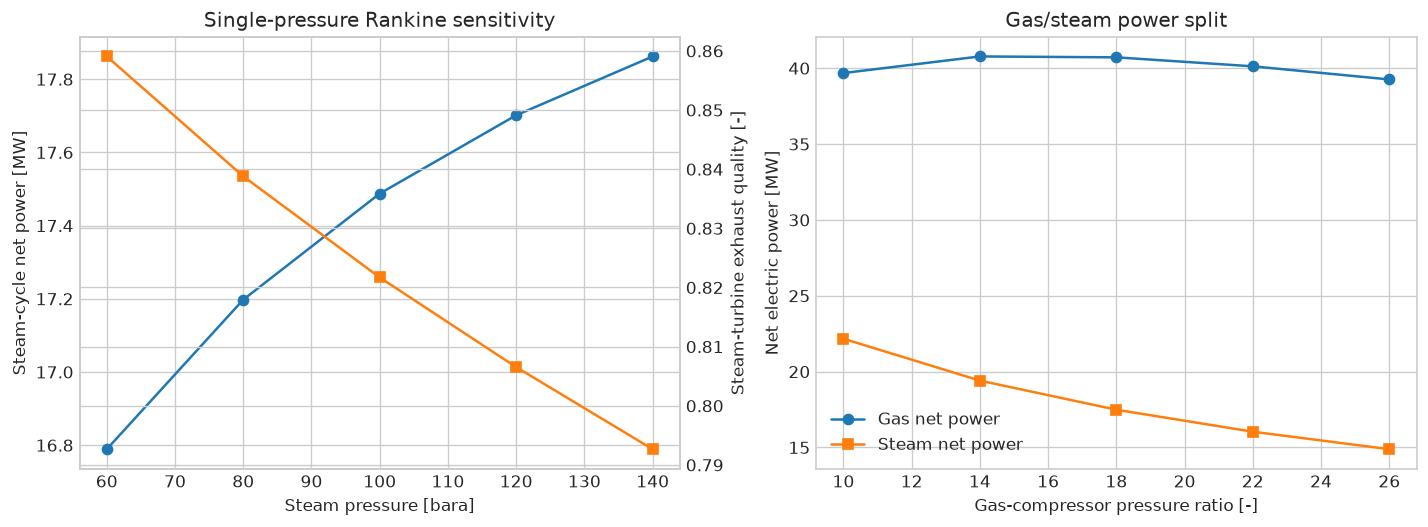

In [20]:
plt.style.use("seaborn-v0_8-whitegrid")
figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(
    steam_pressure_results["Steam pressure [bara]"],
    steam_pressure_results["Steam net power [MW]"],
    marker="o",
    color="tab:blue",
    label="Steam net power",
)
axes[0].set_xlabel("Steam pressure [bara]")
axes[0].set_ylabel("Steam-cycle net power [MW]")
axes[0].set_title("Single-pressure Rankine sensitivity")
quality_axis = axes[0].twinx()
quality_axis.plot(
    steam_pressure_results["Steam pressure [bara]"],
    steam_pressure_results["Exhaust quality [-]"],
    marker="s",
    color="tab:orange",
    label="Exhaust quality",
)
quality_axis.set_ylabel("Steam-turbine exhaust quality [-]")

axes[1].plot(
    pressure_ratio_results["Pressure ratio [-]"],
    pressure_ratio_results["Gas net power [MW]"],
    marker="o",
    label="Gas net power",
)
axes[1].plot(
    pressure_ratio_results["Pressure ratio [-]"],
    pressure_ratio_results["Steam net power [MW]"],
    marker="s",
    label="Steam net power",
)
axes[1].set_xlabel("Gas-compressor pressure ratio [-]")
axes[1].set_ylabel("Net electric power [MW]")
axes[1].set_title("Gas/steam power split")
axes[1].legend()

figure.tight_layout()
plt.show()


## 21. Temperature and power-flow overview

The temperature chart labels both cycles without implying a detailed counter-current HRSG profile.
The power chart separates compressor consumption, gas-turbine production, and the net steam
contribution. Signs are displayed as magnitudes for readability; the balance equations above retain
their physical direction.


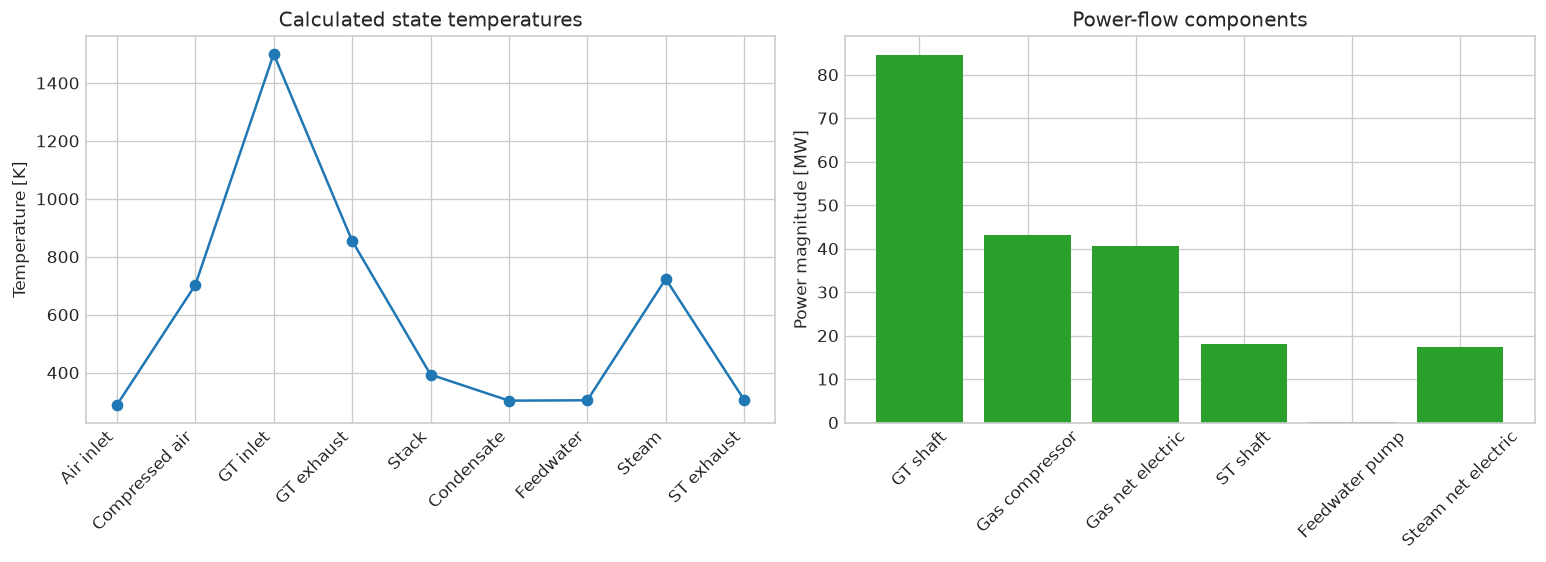

In [21]:
temperature_labels = [
    "Air inlet",
    "Compressed air",
    "GT inlet",
    "GT exhaust",
    "Stack",
    "Condensate",
    "Feedwater",
    "Steam",
    "ST exhaust",
]
temperature_values_k = [
    air_inlet.getTemperature("K"),
    compressed_air.getTemperature("K"),
    combustion_product.getTemperature("K"),
    gas_turbine_outlet.getTemperature("K"),
    stack_gas.getTemperature("K"),
    condensate.getTemperature("K"),
    feedwater.getTemperature("K"),
    superheated_steam.getTemperature("K"),
    steam_turbine_outlet.getTemperature("K"),
]

overview_figure, overview_axes = plt.subplots(1, 2, figsize=(13, 4.8))
overview_axes[0].plot(
    range(len(temperature_labels)),
    temperature_values_k,
    marker="o",
)
overview_axes[0].set_xticks(
    range(len(temperature_labels)),
    temperature_labels,
    rotation=45,
    ha="right",
)
overview_axes[0].set_ylabel("Temperature [K]")
overview_axes[0].set_title("Calculated state temperatures")

power_labels = [
    "GT shaft",
    "Gas compressor",
    "Gas net electric",
    "ST shaft",
    "Feedwater pump",
    "Steam net electric",
]
power_values_mw = [
    gas_turbine_power_kw / 1000.0,
    compressor_power_kw / 1000.0,
    gas_cycle_net_power_kw / 1000.0,
    steam_turbine_power_kw / 1000.0,
    feedwater_pump_power_kw / 1000.0,
    steam_cycle_net_power_kw / 1000.0,
]
overview_axes[1].bar(power_labels, power_values_mw, color="tab:green")
overview_axes[1].tick_params(axis="x", rotation=45)
overview_axes[1].set_ylabel("Power magnitude [MW]")
overview_axes[1].set_title("Power-flow components")

overview_figure.tight_layout()
plt.show()


## Interpretation

The steam bottoming cycle converts part of the exhaust enthalpy that would otherwise leave at the
stack. Its contribution should raise net power and reduce direct kg CO₂/MWh without changing fuel
flow. Boiler pressure influences both steam generation rate and expansion work, while gas-turbine
pressure ratio changes the balance between gas-cycle work and HRSG driving temperature.

The displayed efficiency is a model result, not a benchmark copied from a commercial plant.
Compare only after aligning ambient conditions, fuel, cooling system, degradation, pressure losses,
auxiliary loads, and the LHV/HHV basis.


## Practical limitations and validity limits

- The combustor is non-reacting thermodynamically; chemistry is imposed by atom balance and LHV.
- No nitrogen-oxide, carbon-monoxide, dissociation, pressure-drop, or cooling-air model is included.
- The HRSG has one pressure level and one effectiveness; no economizer/evaporator/superheater
  pinch calculation or heat-transfer sizing is performed.
- The steam turbine has one constant isentropic efficiency and no stage or moisture-loss model.
- The condenser is a fixed pressure and temperature, without cooling-water or air-cooler sizing.
- Generator efficiencies omit balance-of-plant loads such as pumps, fans, treatment, and controls.
- SRK and CPA are appropriate for this educational screen, but design work requires validation
  against plant data, vendor maps, steam tables, and applicable codes.


## Troubleshooting

- If Java does not start, restart the Colab runtime once and rerun from the setup cell.
- If the combustor target is not bracketed, reduce turbine-inlet temperature or raise air flow.
- If the hot-end approach check fails, lower steam temperature or use a lower gas pressure ratio.
- If steam quality is too low, add reheat, reduce boiler pressure, raise superheat, or increase
  condenser pressure after evaluating the efficiency tradeoff.
- If a flash fails after changing conditions, confirm absolute pressure, Kelvin temperature, and
  kJ/kg enthalpy units before loosening solver tolerances.
- Never combine enthalpies from different NeqSim fluid systems unless they appear inside an explicit
  energy balance with a common reference treatment, as done here.


## Summary

This notebook built a genuine combined-cycle screen rather than multiplying exhaust heat by a fixed
efficiency. NeqSim supplied natural-gas heating value, gas-cycle thermodynamic states, CPA
water/steam states, phase quality, and process-equipment cross-checks. Explicit atom, mass, carbon,
combustor, HRSG, Rankine, and solver-agreement checks make the assumptions and numerical closure
visible.


## Further exercises

1. Replace the synthetic fuel with a normalized site composition and compare LHV and carbon
   intensity.
2. Add gas-side and water-side HRSG pressure drops and recompute net efficiency.
3. Split the HRSG into economizer, evaporator, and superheater sections with minimum pinch and
   approach constraints.
4. Add a second steam-pressure level and compare heat recovery and exhaust temperature.
5. Add reheat and quantify the change in steam-turbine exhaust quality.
6. Model condenser cooling-water flow and pump power instead of fixing condenser pressure.
7. Compare SRK-CPA steam enthalpies with an authoritative steam-table implementation over the
   selected pressure and temperature range.


## References

- NeqSim project documentation: https://equinor.github.io/neqsim/
- NeqSim Python package: https://pypi.org/project/neqsim/
- NeqSim source and process-equipment examples:
  https://github.com/equinor/neqsim
- ISO 6976:2016, *Natural gas — Calculation of calorific values, density, relative density and
  Wobbe indices from composition*.
- Moran, Shapiro, Boettner, and Bailey, *Fundamentals of Engineering Thermodynamics*, Wiley.
- Kehlhofer et al., *Combined-Cycle Gas & Steam Turbine Power Plants*, PennWell.

The textbook references support the governing equations. NeqSim documentation and source define the
APIs used in the executable cells.


## Machine-readable run summary

The final cell records the installed NeqSim version, principal outputs, and assertion count. These
values make maintenance regressions easier to detect without replacing the engineering tables.


In [22]:
summary = {
    "neqsim_version": neqsim_version,
    "fuel_lhv_mj_kg": round(fuel_lhv_kj_kg / 1000.0, 6),
    "fuel_flow_kg_s": round(fuel_mass_flow_kg_s, 6),
    "gas_cycle_net_power_mw": round(gas_cycle_net_power_kw / 1000.0, 6),
    "steam_mass_flow_kg_s": round(steam_mass_flow_kg_s, 6),
    "steam_cycle_net_power_mw": round(steam_cycle_net_power_kw / 1000.0, 6),
    "combined_cycle_net_power_mw": round(
        combined_cycle_net_power_kw / 1000.0,
        6,
    ),
    "combined_cycle_efficiency_percent_lhv": round(
        100.0 * combined_cycle_efficiency,
        6,
    ),
    "steam_turbine_exhaust_quality": round(
        steam_outlet_vapor_fraction,
        6,
    ),
    "combined_cycle_direct_co2_kg_mwh": round(
        combined_cycle_co2_kg_mwh,
        3,
    ),
    "engineering_checks_passed": int(sum(validation_checks.values())),
    "engineering_checks_total": len(validation_checks),
}

print(json.dumps(summary, indent=2))


{
  "neqsim_version": "3.16.0",
  "fuel_lhv_mj_kg": 46.051771,
  "fuel_flow_kg_s": 2.595056,
  "gas_cycle_net_power_mw": 40.714009,
  "steam_mass_flow_kg_s": 16.364011,
  "steam_cycle_net_power_mw": 17.48762,
  "combined_cycle_net_power_mw": 58.201629,
  "combined_cycle_efficiency_percent_lhv": 48.701469,
  "steam_turbine_exhaust_quality": 0.821697,
  "combined_cycle_direct_co2_kg_mwh": 420.203,
  "engineering_checks_passed": 19,
  "engineering_checks_total": 19
}
